In [1]:
%matplotlib inline
# changed from %matplotlib notebook as graphs werent being plotted 

In [2]:
from Bio.Align import PairwiseAligner, substitution_matrices
from Bio.Seq import Seq 
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO
import numpy as np
from numpy import random as rd
from matplotlib import pyplot as plt

In [3]:
from src.estimalign import estimalign
from src.logit_link import logit_partial_scores
from src.optimization import create_powerstep, create_constant_step

# Data

In [4]:
from miRBench.dataset import list_datasets, get_dataset_df

In [5]:
hejret_train = get_dataset_df(list_datasets()[0], split="train")
hejret_test = get_dataset_df(list_datasets()[0], split="test")

Using cached dataset /home/dave/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/train/dataset.tsv
Using cached dataset /home/dave/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/test/dataset.tsv


In [6]:
mirlist = hejret_train['noncodingRNA']
mirlist = [Seq(seq) for seq in mirlist]
genelist = hejret_train['gene']
genelist = [Seq(seq).reverse_complement() for seq in genelist]

# Optimization

### Simple model on miRNA alignments:

In [7]:
true_match = 1
true_mismatch = -1
true_gapopen = -1.2
true_gapext = -0.1

In [8]:
aligner = PairwiseAligner()
aligner.mode = 'local'
aligner.open_gap_score = true_gapopen
aligner.extend_gap_score = true_gapext
aligner.match = true_match
aligner.mismatch = true_mismatch
# aligner.end_gap_score = 0

In [9]:
scores = np.array([aligner.score(a, b) for a, b in zip(mirlist, genelist)])

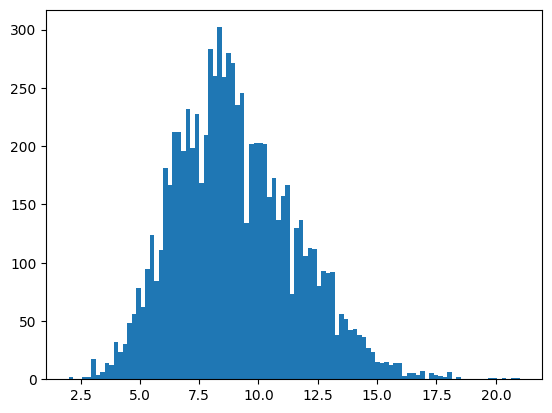

In [10]:
plt.figure()
plt.hist(scores, bins=100)
plt.show()

In [11]:
true_alpha = -9
## true_alpha = -np.median(scores)

In [12]:
logit_scores = logit_partial_scores(scores, true_alpha)

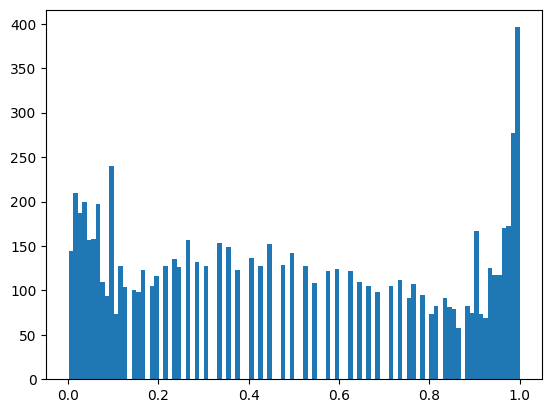

In [13]:
plt.figure()
plt.hist(logit_scores, bins=100)
plt.show()

### Test Run

In [14]:
labels = rd.rand(len(mirlist))
labels = labels <= logit_scores
labels

array([False,  True, False, ..., False, False,  True], shape=(8193,))

In [15]:
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
print('Sum of log-logit scores:', np.sum(np.log(logit_scores)))
print('True LogL:', true_logL) ## This is different 

Sum of log-logit scores: -10002.78024009512
True LogL: -3298.2802400951223


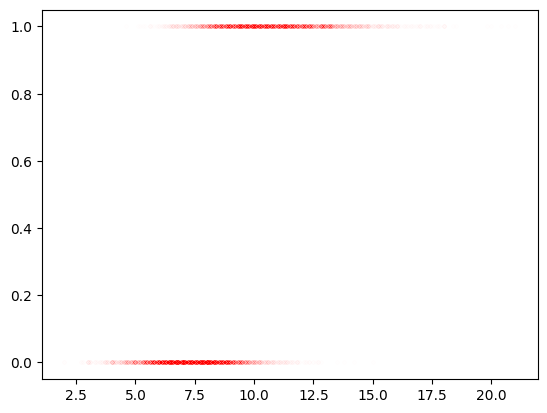

In [16]:
plt.figure()
plt.plot(scores, labels, 'r.', alpha=0.005)

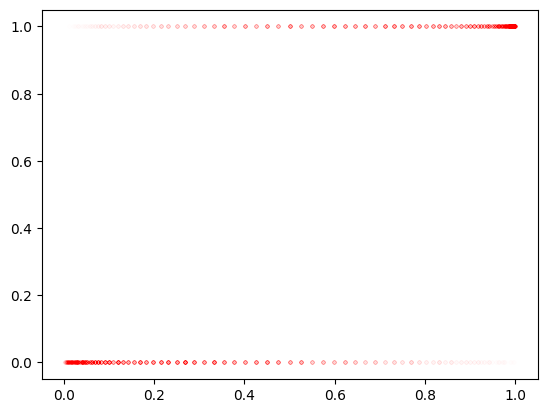

In [17]:
plt.figure()
plt.plot(logit_scores, labels, 'r.', alpha=0.005)

In [18]:
const_step = create_constant_step(0.00001)
# powerstep = create_powerstep(0.00001, power=0.5, burnin=0)
# powerstep = create_powerstep(0.00001, power=-0.5, burnin=0)

In [19]:
NITER = 50 # original 50

In [20]:
params = estimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='simple',
                    verbose=True, max_iter=NITER,
                    stochastic_factor=None,
                    num_threads = 16)

Alphabet:
TACG


/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Initial parameters:
{'alpha': np.float64(-8.003302344121712), 'match_score': np.float64(0.939211480149184), 'mismatch_score': np.float64(-0.8635627449034454), 'open_gap_score': np.float64(-1.2492914520096585), 'extend_gap_score': np.float64(-0.09038659127006578)}
Start of iteration 0
Current alpha: -8.003302344121712
Current logL: -3337.7736587803447
Updated alpha: -8.153619976720034
Updated logL: -3325.2298091795706
New subgradient:
{'Substitutions': Array([[ 98.51918392, -22.58026647, -34.30386314, -10.91507075],
       [-17.89170955,   6.32311532,   2.05175845,  -3.74612365],
       [ -7.62481861, -10.90708657, 138.02520144, -26.72307548],
       [-14.41132842, -12.72783087, -26.02510539,  50.53700717]],
         alphabet='TACG'), 'Gap opens': np.float64(237.3529681899035), 'Gap extends': np.float64(439.1796338002731)}
Stepsize: 1e-05
Gap open step: 0.002373529681899035
Gap extend step: 0.004391796338002732
Match step: 0.0029340450784562234
Mismatch step: -0.0018580452043781299
New 

In [21]:
print(params['final_loglik'])

-3301.810772170581


In [22]:
print(params['final_loglik'])

-3301.810772170581


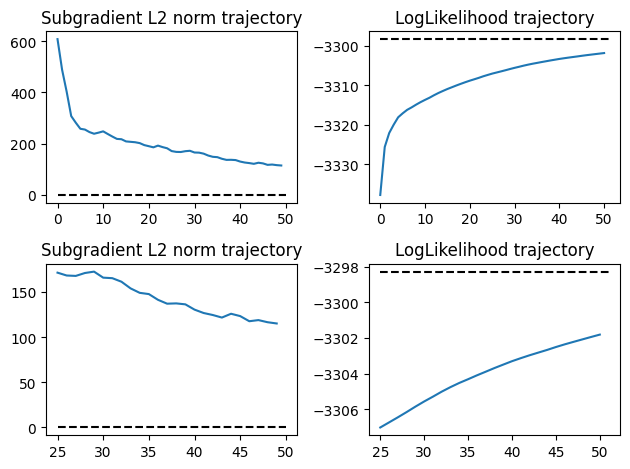

In [23]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

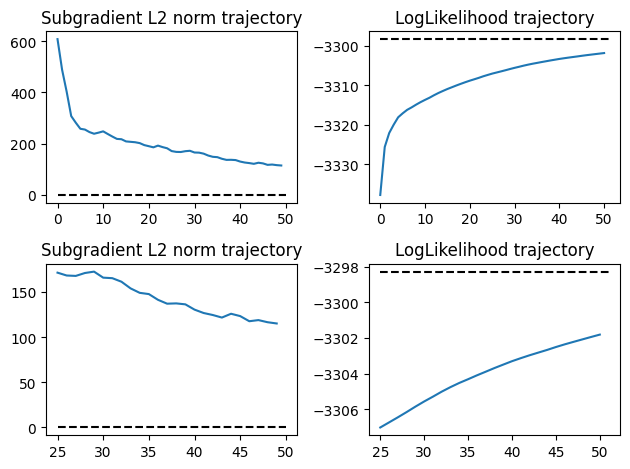

In [24]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

In [25]:
print(true_match, params['match_score'])
print(true_mismatch, params['mismatch_score'])
print(true_gapopen, params['open_gap_score'])
print(true_gapext, params['extend_gap_score'])
print(true_alpha, params['alpha'])

1 0.9804539803744705
-1 -0.9286309552225633
-1.2 -1.1966088306171683
-0.1 -0.09202584304569328
-9 -8.838261296797006


### Step function parameters experiment

In [29]:
labels = rd.rand(len(mirlist)) <= logit_scores

In [30]:
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))

In [31]:
steplengths = np.linspace(0.000005, 0.00005, num=10)
steplengths

array([5.0e-06, 1.0e-05, 1.5e-05, 2.0e-05, 2.5e-05, 3.0e-05, 3.5e-05,
       4.0e-05, 4.5e-05, 5.0e-05])

In [ ]:
NITER = 10

In [ ]:
# Get the iteration at which logL is hit (speed)
def get_logL__reached_iter(params, true_logL):
    for i, logL in enumerate(params['loglik_trajectory']):
        if logL == true_logL:
            return i
    
    print("Did not rach LogLikelihood")
    return None

In [ ]:
# Get the value at the last iteration of the simulation
def get_final_val(params):
    return params['loglik_trajectory'][-1]

In [ ]:
estimalign_results_step = []

logL_reached_iters = []
final_vals = []

for stepl in steplengths:
    const_step = create_constant_step(stepl)
    
    params = estimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='simple',
                    gap_mode = 'affine',
                    verbose=False, max_iter=NITER,
                    stochastic_factor=0.001,
                    num_threads = 16)
    estimalign_results_step.append(params)

    logL_reached_iter = get_logL__reached_iter(params, true_logL)
    logL_reached_iters.append(logL_reached_iter if logL_reached_iter is not None else np.inf) # infinity so that they dont show on the scatter plot 

    final_val = get_final_val(params)
    final_vals.append(final_val)

    if logL_reached_iter < NITER:
        print(f"step={stepl:.2e}, hit logL at {logL_reached_iter}")
    else:
        print(f"step={stepl:.2e}, did NOT hit logL") 

/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


step=5.00e-06, penalty=0.1616, did NOT converge


/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


step=1.00e-05, penalty=1.5392, converged at iteration 101


/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


...

step=4.00e-05, penalty=2.1306, converged at iteration 25


/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


step=4.50e-05, penalty=2.1301, converged at iteration 23


/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


step=5.00e-05, penalty=1.1922, converged at iteration 24

Best step to be used for replicate experiment:  5e-06


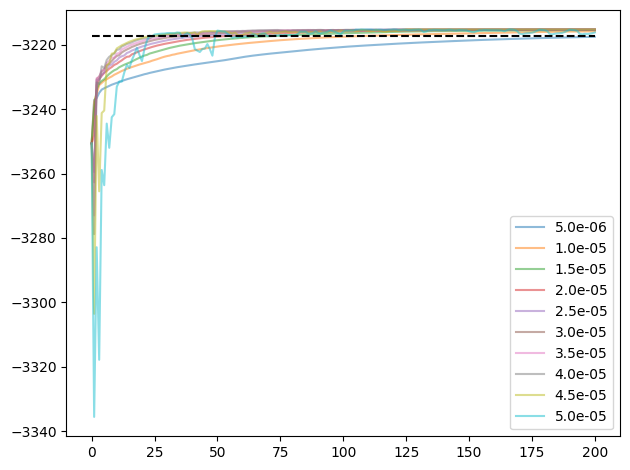

In [ ]:
plt.figure()
for params in estimalign_results_step:
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'], alpha=0.5)
plt.plot([0, NITER], [true_logL, true_logL], 'k--')
plt.legend([f"{sl:.1e}" for sl in steplengths])
plt.tight_layout()
# plt.savefig('path', dpi=160)

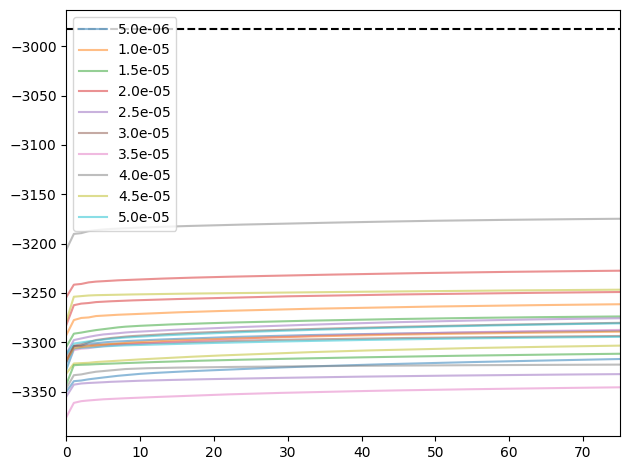

In [ ]:
# below needs to be done again 
plt.figure()
for params in estimalign_results_step:
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'], alpha=0.5)
plt.plot([0, NITER], [true_logL, true_logL], 'k--')
plt.legend([f"{sl:.1e}" for sl in steplengths])
plt.xlim(25, 75) 
plt.ylim(3250, 3200)
plt.tight_layout()

In [ ]:
# below needs to be done again 
plt.figure()
for params in estimalign_results_step:
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'], alpha=0.5)
plt.plot([0, NITER], [true_logL, true_logL], 'k--')
plt.legend([f"{sl:.1e}" for sl in steplengths])
plt.xlim(180, 200) 
plt.ylim(3220, 3180)
plt.tight_layout()

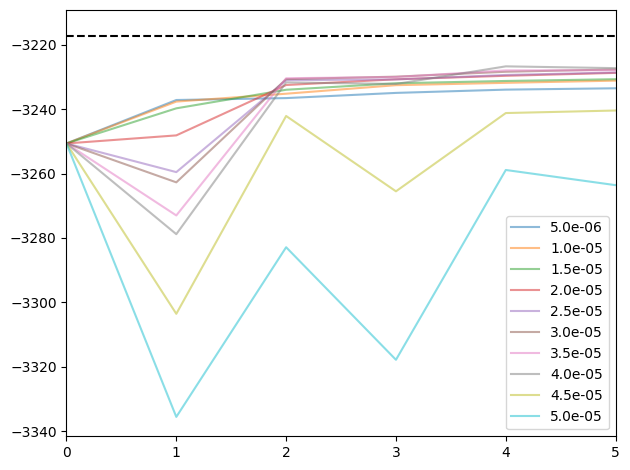

In [ ]:
plt.figure()
for params in estimalign_results_step:
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'], alpha=0.5)
plt.plot([0, NITER], [true_logL, true_logL], 'k--')
plt.legend([f"{sl:.1e}" for sl in steplengths])
plt.xlim(0, 5)
plt.tight_layout()

In [ ]:
plt.figure()

logL_reached_iters_arr = np.array(logL_reached_iters)
final_vals_arr = np.array(final_vals)

plt.scatter(logL_reached_iters_arr, final_vals_arr)

for i, steplength in enumerate(steplengths):
    if np.isfinite(logL_reached_iters_arr[i]):
        plt.annotate(
            f"{steplength:.2e}",
            (logL_reached_iters_arr[i], final_vals_arr[i])
        )

plt.xlabel("Iteration where true logL is first reached")
plt.ylabel("Final log-likelihood at last iteration")
plt.tight_layout()

### Replicates

In [ ]:
REPS = 20
NITER = 10

In [ ]:
const_step = create_constant_step(3.0e-05) # updated to choose best step from prev exp 
# const_step = create_constant_step(0.00001)
# powerstep = create_powerstep(0.00001, power=0.5, burnin=0)
# powerstep = create_powerstep(0.00001, power=-0.5, burnin=0)

In [ ]:
# Checks if the chosen step size is stable in convergence across different datasets
estimalign_results_rep = []
true_logLs = []

logL_reached_iters_rep = []
final_vals_rep = []

for _ in range(REPS):
    labels = rd.rand(len(mirlist)) <= logit_scores
    true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
    true_logLs.append(true_logL)
    params = estimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='simple',
                    gap_mode = 'affine',
                    verbose=False, max_iter=NITER,
                    stochastic_factor=0.001,
                    num_threads = 16)
    estimalign_results_rep.append(params)

    logL_reached_iter = get_logL__reached_iter(params, true_logL)
    
    logL_reached_iters_rep.append(
        logL_reached_iter if logL_reached_iter is not None else np.inf
    )

    final_vals_rep.append(get_final_val(params))

for i, it in enumerate(logL_reached_iters_rep):
    if np.isfinite(it):
        print(f"rep {i} hit logL at iteration {it}, final={final_vals_rep[i]:.2f}")
    else:
        print(f"rep {i} did NOT hit logL, final={final_vals_rep[i]:.2f}")

/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

rep 0 converged at iteration 173
rep 1 converged at iteration 181
rep 2 converged at iteration 142
rep 3 converged at iteration 177
rep 4 converged at iteration 48
rep 5 did NOT converge
rep 6 converged at iteration 130
rep 7 converged at iteration 128
rep 8 did NOT converge
rep 9 did NOT converge
rep 10 did NOT converge
rep 11 did NOT converge
rep 12 converged at iteration 114
rep 13 converged at iteration 109
rep 14 converged at iteration 165
rep 15 converged at iteration 198
rep 16 did NOT converge
rep 17 converged at iteration 14
rep 18 converged at iteration 167
rep 19 did NOT converge


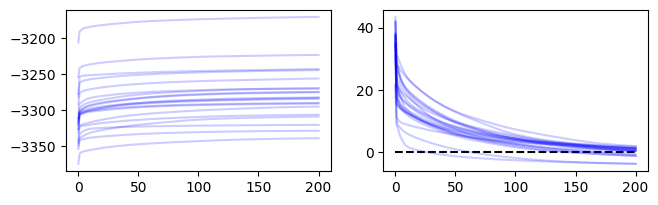

In [ ]:
plt.figure(figsize=(7.5, 2.1))
plt.subplot(121)
for params in estimalign_results_rep:
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'], alpha=0.2, color='b')
plt.subplot(122)
plt.plot([0, NITER], [0, 0], 'k--')
for params, tlL in zip(estimalign_results_rep, true_logLs):
    plt.plot(np.arange(NITER+1), tlL - params['loglik_trajectory'], alpha=0.2, color='b')